# Stage 0 — COSMOS Manual Cutout Preparation (Clean Version)

**Purpose:** Build a clean source-galaxy library from **manually downloaded** COSMOS HST/ACS F814W FITS cutouts for later lenstronomy simulations.

This notebook intentionally removes all automatic IRSA query/download logic to avoid confusion.

## What this notebook does
1. Reads manually downloaded FITS cutouts from a folder.
2. Extracts sky coordinates from the filename when possible, with WCS fallback.
3. Performs basic image-level QA suited to manual-download workflows.
4. Normalises accepted cutouts and saves them as `.npy` arrays.
5. Writes clean metadata to JSON and CSV.
6. Produces a summary grid JPG for visual inspection.

## Important note
Because you are downloading files manually, **catalog-based star rejection is not being applied here automatically**. You must ensure the FITS files you place in the input folder are already your intended galaxy sample, and this notebook adds only image-level QA plus manual-review support.

## Cell 1 — Install dependencies (run once)

This version uses only packages needed for a **manual FITS workflow**.

In [1]:
import subprocess
import sys

packages = [
    'numpy',
    'pandas',
    'matplotlib',
    'astropy',
    'tqdm',
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('Manual-workflow dependencies installed successfully.')

Manual-workflow dependencies installed successfully.


## Cell 2 — Imports and configuration

Set the input folder to wherever you saved your manually downloaded FITS files.

The default pixel scale here is **0.03 arcsec/pixel**, matching COSMOS ACS 30 mas mosaic products. A 10.0 arcsec cutout therefore corresponds to roughly **333–335 pixels** per side, which is consistent with your current files.

In [1]:
import json
import math
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u

warnings.filterwarnings('ignore')

# =========================
# User configuration
# =========================
RAW_DIR = Path('cosmos_cutouts/fits')
OUT_DIR = Path('cosmos_cutouts')
NPY_DIR = OUT_DIR / 'npy'
META_DIR = OUT_DIR / 'metadata'
PLOT_DIR = OUT_DIR / 'qa_plots'

for d in [RAW_DIR, OUT_DIR, NPY_DIR, META_DIR, PLOT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CUTOUT_SIZE_ARCSEC = 10.0
DEFAULT_PIXEL_SCALE_ARCSEC = 0.03
EXPECTED_SIZE_PIX = int(round(CUTOUT_SIZE_ARCSEC / DEFAULT_PIXEL_SCALE_ARCSEC))

# Manual-review controls
MAX_FILES = None          # set to an integer for testing, e.g. 50
REJECT_BY_FILENAME = set()  # e.g. {'0045_150.143014_2.219132_acs_I_mosaic_30mas_sci.fits'}

# Simple image-level QA thresholds
MIN_STD = 0.003
MAX_PEAK_AFTER_NORM = 20.0
MAX_EDGE_ABS_MEAN = 0.50
MIN_FINITE_FRACTION = 0.98

print(f'Input FITS folder      : {RAW_DIR.resolve()}')
print(f'Output folder          : {OUT_DIR.resolve()}')
print(f'Cutout size            : {CUTOUT_SIZE_ARCSEC:.1f}"')
print(f'Default pixel scale    : {DEFAULT_PIXEL_SCALE_ARCSEC:.3f}"/pixel')
print(f'Expected size (~)      : {EXPECTED_SIZE_PIX} px per side')

Input FITS folder      : C:\Users\upraj\Prajwal\GSOC\DeepLense\DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday\cosmos_cutouts\fits
Output folder          : C:\Users\upraj\Prajwal\GSOC\DeepLense\DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday\cosmos_cutouts
Cutout size            : 10.0"
Default pixel scale    : 0.030"/pixel
Expected size (~)      : 333 px per side


## Cell 3 — Discover manual FITS files

This cell only inspects the input folder and builds the list of candidate files.

In [2]:
fits_files = sorted(RAW_DIR.glob('*.fits')) + sorted(RAW_DIR.glob('*.fit'))

if MAX_FILES is not None:
    fits_files = fits_files[:MAX_FILES]

print(f'Found {len(fits_files)} FITS files.')
for fp in fits_files[:10]:
    print(' -', fp.name)

if len(fits_files) == 0:
    print('No FITS files found. Put your manually downloaded COSMOS cutouts into RAW_DIR and rerun.')

Found 50 FITS files.
 - 0001_150.329073_2.139497_acs_I_mosaic_30mas_sci.fits
 - 0002_150.054801_2.426702_acs_I_mosaic_30mas_sci.fits
 - 0003_150.218429_2.36785_acs_I_mosaic_30mas_sci.fits
 - 0004_150.293615_2.402216_acs_I_mosaic_30mas_sci.fits
 - 0005_150.300439_2.165881_acs_I_mosaic_30mas_sci.fits
 - 0006_149.7983_2.215854_acs_I_mosaic_30mas_sci.fits
 - 0007_149.825905_2.27702_acs_I_mosaic_30mas_sci.fits
 - 0008_150.110179_2.272575_acs_I_mosaic_30mas_sci.fits
 - 0009_150.028484_2.13021_acs_I_mosaic_30mas_sci.fits
 - 0010_150.186217_2.556423_acs_I_mosaic_30mas_sci.fits


## Cell 4 — Helper functions

These helpers do the following:
- recover RA/Dec from the filename when available,
- fall back to FITS WCS if the filename does not contain coordinates,
- estimate pixel scale from the WCS when possible,
- normalise cutouts for downstream use,
- run simple image-level QA suitable for a manual workflow.

In [3]:
COORD_PATTERN = re.compile(r'(?P<idx>\d+)_(?P<ra>\d+\.\d+)_(?P<dec>[+-]?\d+\.\d+)_')


def parse_coords_from_filename(filename):
    m = COORD_PATTERN.search(filename)
    if m is None:
        return None, None
    return float(m.group('ra')), float(m.group('dec'))


def get_center_coords_from_wcs(header, shape):
    try:
        w = WCS(header)
        if not w.has_celestial:
            return None, None
        ny, nx = shape
        x_center = (nx - 1) / 2.0
        y_center = (ny - 1) / 2.0
        ra, dec = w.all_pix2world(x_center, y_center, 0)
        return float(ra), float(dec)
    except Exception:
        return None, None


def get_pixel_scale_arcsec(header):
    try:
        w = WCS(header)
        if not w.has_celestial:
            return DEFAULT_PIXEL_SCALE_ARCSEC
        scales = proj_plane_pixel_scales(w.celestial) * 3600.0
        scales = np.asarray(scales, dtype=float)
        if np.all(np.isfinite(scales)) and np.all(scales > 0):
            return float(np.mean(scales))
    except Exception:
        pass
    return DEFAULT_PIXEL_SCALE_ARCSEC


def robust_normalize(img):
    img = np.array(img, dtype=np.float32)
    finite = np.isfinite(img)
    finite_fraction = float(finite.mean())
    img = np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)

    sky_level = float(np.median(img))
    img_sub = img - sky_level

    p99_flux = float(np.percentile(img_sub, 99.0))
    scale = p99_flux if p99_flux > 0 else 1.0

    norm = (img_sub / scale).astype(np.float32)
    norm = np.clip(norm, -1.0, 5.0)

    return norm, sky_level, p99_flux, finite_fraction


def edge_abs_mean(arr):
    edge = np.concatenate([arr[0, :], arr[-1, :], arr[:, 0], arr[:, -1]])
    return float(np.mean(np.abs(edge)))


def qa_checks(norm, finite_fraction, filename):
    reasons = []

    if filename in REJECT_BY_FILENAME:
        reasons.append('manual_filename_reject')

    std = float(np.std(norm))
    peak = float(np.max(norm))
    edge_mean = edge_abs_mean(norm)

    if finite_fraction < MIN_FINITE_FRACTION:
        reasons.append('too_many_nonfinite_pixels')
    if std < MIN_STD:
        reasons.append('near_empty_or_too_flat')
    if peak > MAX_PEAK_AFTER_NORM:
        reasons.append('extreme_peak_possible_star_or_artifact')
    if edge_mean > MAX_EDGE_ABS_MEAN:
        reasons.append('strong_edge_signal_possible_bad_crop')

    return reasons, {
        'std_norm': std,
        'peak_norm': peak,
        'edge_abs_mean': edge_mean,
        'finite_fraction': finite_fraction,
    }

## Cell 5 — Read FITS files and build a manifest

This cell creates a table describing every available manual cutout **before** any acceptance/rejection decision is made.

In [4]:
manifest = []
image_store = {}

for fp in tqdm(fits_files, desc='Reading FITS files'):
    try:
        with fits.open(fp, memmap=False) as hdul:
            data = hdul[0].data
            header = hdul[0].header

        if data is None:
            manifest.append({'filename': fp.name, 'status': 'reject', 'reason': 'empty_primary_hdu'})
            continue

        data = np.squeeze(np.array(data))
        if data.ndim != 2:
            manifest.append({'filename': fp.name, 'status': 'reject', 'reason': f'non_2d_shape_{data.shape}'})
            continue

        ra, dec = parse_coords_from_filename(fp.name)
        if ra is None or dec is None:
            ra, dec = get_center_coords_from_wcs(header, data.shape)

        pixel_scale = get_pixel_scale_arcsec(header)
        norm, sky_level, p99_flux, finite_fraction = robust_normalize(data)
        qa_reasons, qa_stats = qa_checks(norm, finite_fraction, fp.name)

        status = 'accept' if len(qa_reasons) == 0 else 'reject'
        reason = ';'.join(qa_reasons) if qa_reasons else 'passed_basic_qa'

        record = {
            'filename': fp.name,
            'path': str(fp),
            'ra': None if ra is None else float(ra),
            'dec': None if dec is None else float(dec),
            'shape_y': int(data.shape[0]),
            'shape_x': int(data.shape[1]),
            'pixel_scale_arcsec': float(pixel_scale),
            'cutout_size_arcsec_y': float(data.shape[0] * pixel_scale),
            'cutout_size_arcsec_x': float(data.shape[1] * pixel_scale),
            'sky_level': float(sky_level),
            'p99_flux': float(p99_flux),
            'status': status,
            'reason': reason,
            **qa_stats,
        }
        manifest.append(record)
        image_store[fp.name] = norm

    except Exception as e:
        manifest.append({'filename': fp.name, 'status': 'reject', 'reason': f'exception: {type(e).__name__}: {e}'})

manifest_df = pd.DataFrame(manifest)
manifest_df.head()

Reading FITS files:   0%|          | 0/50 [00:00<?, ?it/s]

,filename,path,ra,dec,shape_y,shape_x,pixel_scale_arcsec,cutout_size_arcsec_y,cutout_size_arcsec_x,sky_level,p99_flux,status,reason,std_norm,peak_norm,edge_abs_mean,finite_fraction
0,0001_150.329073_2.139497_acs_I_mosaic_30mas_sc...,cosmos_cutouts\fits\0001_150.329073_2.139497_a...,150.329073,2.139497,335,335,0.03,10.05,10.05,0.002171,0.215630,accept,passed_basic_qa,0.198965,3.682375,0.012155,1.0
1,0002_150.054801_2.426702_acs_I_mosaic_30mas_sc...,cosmos_cutouts\fits\0002_150.054801_2.426702_a...,150.054801,2.426702,335,335,0.03,10.05,10.05,0.000263,0.052800,accept,passed_basic_qa,0.269309,5.000000,0.039929,1.0
2,0003_150.218429_2.36785_acs_I_mosaic_30mas_sci...,cosmos_cutouts\fits\0003_150.218429_2.36785_ac...,150.218429,2.367850,335,335,0.03,10.05,10.05,0.000665,0.166608,accept,passed_basic_qa,0.220403,5.000000,0.012844,1.0
3,0004_150.293615_2.402216_acs_I_mosaic_30mas_sc...,cosmos_cutouts\fits\0004_150.293615_2.402216_a...,150.293615,2.402216,335,335,0.03,10.05,10.05,0.000153,0.020174,accept,passed_basic_qa,0.272316,5.000000,0.098457,1.0
4,0005_150.300439_2.165881_acs_I_mosaic_30mas_sc...,cosmos_cutouts\fits\0005_150.300439_2.165881_a...,150.300439,2.165881,335,335,0.03,10.05,10.05,0.000246,0.012684,accept,passed_basic_qa,0.325953,5.000000,0.155527,1.0


## Cell 6 — Inspect acceptance/rejection summary

Because this is a manual-download notebook, this summary is your main sanity check before export.

In [5]:
print('Total files   :', len(manifest_df))
print('Accepted      :', int((manifest_df['status'] == 'accept').sum()))
print('Rejected      :', int((manifest_df['status'] == 'reject').sum()))

print('Rejection reasons:')
print(manifest_df['reason'].value_counts(dropna=False).head(20))

accepted_df = manifest_df[manifest_df['status'] == 'accept'].copy().reset_index(drop=True)
rejected_df = manifest_df[manifest_df['status'] == 'reject'].copy().reset_index(drop=True)

accepted_df.head()

Total files   : 50
Accepted      : 50
Rejected      : 0
Rejection reasons:
reason
passed_basic_qa    50
Name: count, dtype: int64


,filename,path,ra,dec,shape_y,shape_x,pixel_scale_arcsec,cutout_size_arcsec_y,cutout_size_arcsec_x,sky_level,p99_flux,status,reason,std_norm,peak_norm,edge_abs_mean,finite_fraction
0,0001_150.329073_2.139497_acs_I_mosaic_30mas_sc...,cosmos_cutouts\fits\0001_150.329073_2.139497_a...,150.329073,2.139497,335,335,0.03,10.05,10.05,0.002171,0.215630,accept,passed_basic_qa,0.198965,3.682375,0.012155,1.0
1,0002_150.054801_2.426702_acs_I_mosaic_30mas_sc...,cosmos_cutouts\fits\0002_150.054801_2.426702_a...,150.054801,2.426702,335,335,0.03,10.05,10.05,0.000263,0.052800,accept,passed_basic_qa,0.269309,5.000000,0.039929,1.0
2,0003_150.218429_2.36785_acs_I_mosaic_30mas_sci...,cosmos_cutouts\fits\0003_150.218429_2.36785_ac...,150.218429,2.367850,335,335,0.03,10.05,10.05,0.000665,0.166608,accept,passed_basic_qa,0.220403,5.000000,0.012844,1.0
3,0004_150.293615_2.402216_acs_I_mosaic_30mas_sc...,cosmos_cutouts\fits\0004_150.293615_2.402216_a...,150.293615,2.402216,335,335,0.03,10.05,10.05,0.000153,0.020174,accept,passed_basic_qa,0.272316,5.000000,0.098457,1.0
4,0005_150.300439_2.165881_acs_I_mosaic_30mas_sc...,cosmos_cutouts\fits\0005_150.300439_2.165881_a...,150.300439,2.165881,335,335,0.03,10.05,10.05,0.000246,0.012684,accept,passed_basic_qa,0.325953,5.000000,0.155527,1.0


## Cell 7 — Optional manual review list

Use this cell after looking at the grid later. Add filenames you do **not** want in the final source library, then rerun Cells 5 onward.

In [6]:
# Example:
# REJECT_BY_FILENAME = {
#     '0045_150.143014_2.219132_acs_I_mosaic_30mas_sci.fits',
#     '0047_150.062815_2.100594_acs_I_mosaic_30mas_sci.fits',
# }
print('Manual reject list size:', len(REJECT_BY_FILENAME))

Manual reject list size: 0


## Cell 8 — Save accepted cutouts as `.npy` and write metadata

This is the main export step. It writes:
- one `.npy` file per accepted cutout,
- `cutout_metadata.json`,
- `cutout_manifest.csv`,
- `accepted_cutouts.csv`,
- `rejected_cutouts.csv`.

In [7]:
for old_file in NPY_DIR.glob('*.npy'):
    old_file.unlink()

metadata = []

for _, row in accepted_df.iterrows():
    filename = row['filename']
    arr = image_store[filename]
    stem = Path(filename).stem
    npy_name = f'{stem}.npy'
    np.save(NPY_DIR / npy_name, arr)

    metadata.append({
        'filename': filename,
        'npy_name': npy_name,
        'ra': None if pd.isna(row.get('ra')) else float(row['ra']),
        'dec': None if pd.isna(row.get('dec')) else float(row['dec']),
        'shape': [int(arr.shape[0]), int(arr.shape[1])],
        'pixel_scale_arcsec': None if pd.isna(row.get('pixel_scale_arcsec')) else float(row['pixel_scale_arcsec']),
        'cutout_size_arcsec': CUTOUT_SIZE_ARCSEC,
        'sky_level': None if pd.isna(row.get('sky_level')) else float(row['sky_level']),
        'p99_flux': None if pd.isna(row.get('p99_flux')) else float(row['p99_flux']),
        'std_norm': None if pd.isna(row.get('std_norm')) else float(row['std_norm']),
        'peak_norm': None if pd.isna(row.get('peak_norm')) else float(row['peak_norm']),
        'edge_abs_mean': None if pd.isna(row.get('edge_abs_mean')) else float(row['edge_abs_mean']),
    })

with open(META_DIR / 'cutout_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

manifest_df.to_csv(META_DIR / 'cutout_manifest.csv', index=False)
accepted_df.to_csv(META_DIR / 'accepted_cutouts.csv', index=False)
rejected_df.to_csv(META_DIR / 'rejected_cutouts.csv', index=False)

print(f'Saved {len(metadata)} .npy files to: {NPY_DIR.resolve()}')
print(f'Metadata JSON written to: {(META_DIR / "cutout_metadata.json").resolve()}')
print(f'Manifest CSV written to : {(META_DIR / "cutout_manifest.csv").resolve()}')

Saved 50 .npy files to: C:\Users\upraj\Prajwal\GSOC\DeepLense\DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday\cosmos_cutouts\npy
Metadata JSON written to: C:\Users\upraj\Prajwal\GSOC\DeepLense\DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday\cosmos_cutouts\metadata\cutout_metadata.json
Manifest CSV written to : C:\Users\upraj\Prajwal\GSOC\DeepLense\DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday\cosmos_cutouts\metadata\cutout_manifest.csv


## Cell 9 — Verify that `.npy` export actually happened

This cell exists specifically to avoid the previous confusion where the `.npy` folder ended up empty.

In [8]:
saved_npy = sorted(NPY_DIR.glob('*.npy'))
print(f'Number of saved .npy files: {len(saved_npy)}')

for fp in saved_npy[:10]:
    arr = np.load(fp)
    print(fp.name, arr.shape, arr.dtype, float(arr.min()), float(arr.max()))

Number of saved .npy files: 50
0001_150.329073_2.139497_acs_I_mosaic_30mas_sci.npy (335, 335) float32 -0.07093432545661926 3.682375192642212
0002_150.054801_2.426702_acs_I_mosaic_30mas_sci.npy (335, 335) float32 -0.22975102066993713 5.0
0003_150.218429_2.36785_acs_I_mosaic_30mas_sci.npy (335, 335) float32 -0.07386192679405212 5.0
0004_150.293615_2.402216_acs_I_mosaic_30mas_sci.npy (335, 335) float32 -0.6751198768615723 5.0
0005_150.300439_2.165881_acs_I_mosaic_30mas_sci.npy (335, 335) float32 -0.8430550694465637 5.0
0006_149.7983_2.215854_acs_I_mosaic_30mas_sci.npy (335, 335) float32 -1.0 5.0
0007_149.825905_2.27702_acs_I_mosaic_30mas_sci.npy (335, 335) float32 -0.12630069255828857 5.0
0008_150.110179_2.272575_acs_I_mosaic_30mas_sci.npy (335, 335) float32 -0.9584959149360657 4.767162322998047
0009_150.028484_2.13021_acs_I_mosaic_30mas_sci.npy (335, 335) float32 -0.9133205413818359 3.469642162322998
0010_150.186217_2.556423_acs_I_mosaic_30mas_sci.npy (335, 335) float32 -0.30581074953079

## Cell 10 — Create a summary grid JPG for visual inspection

This grid is for quick morphology and artifact inspection. It should be reviewed manually before using the source library in lenstronomy simulations.

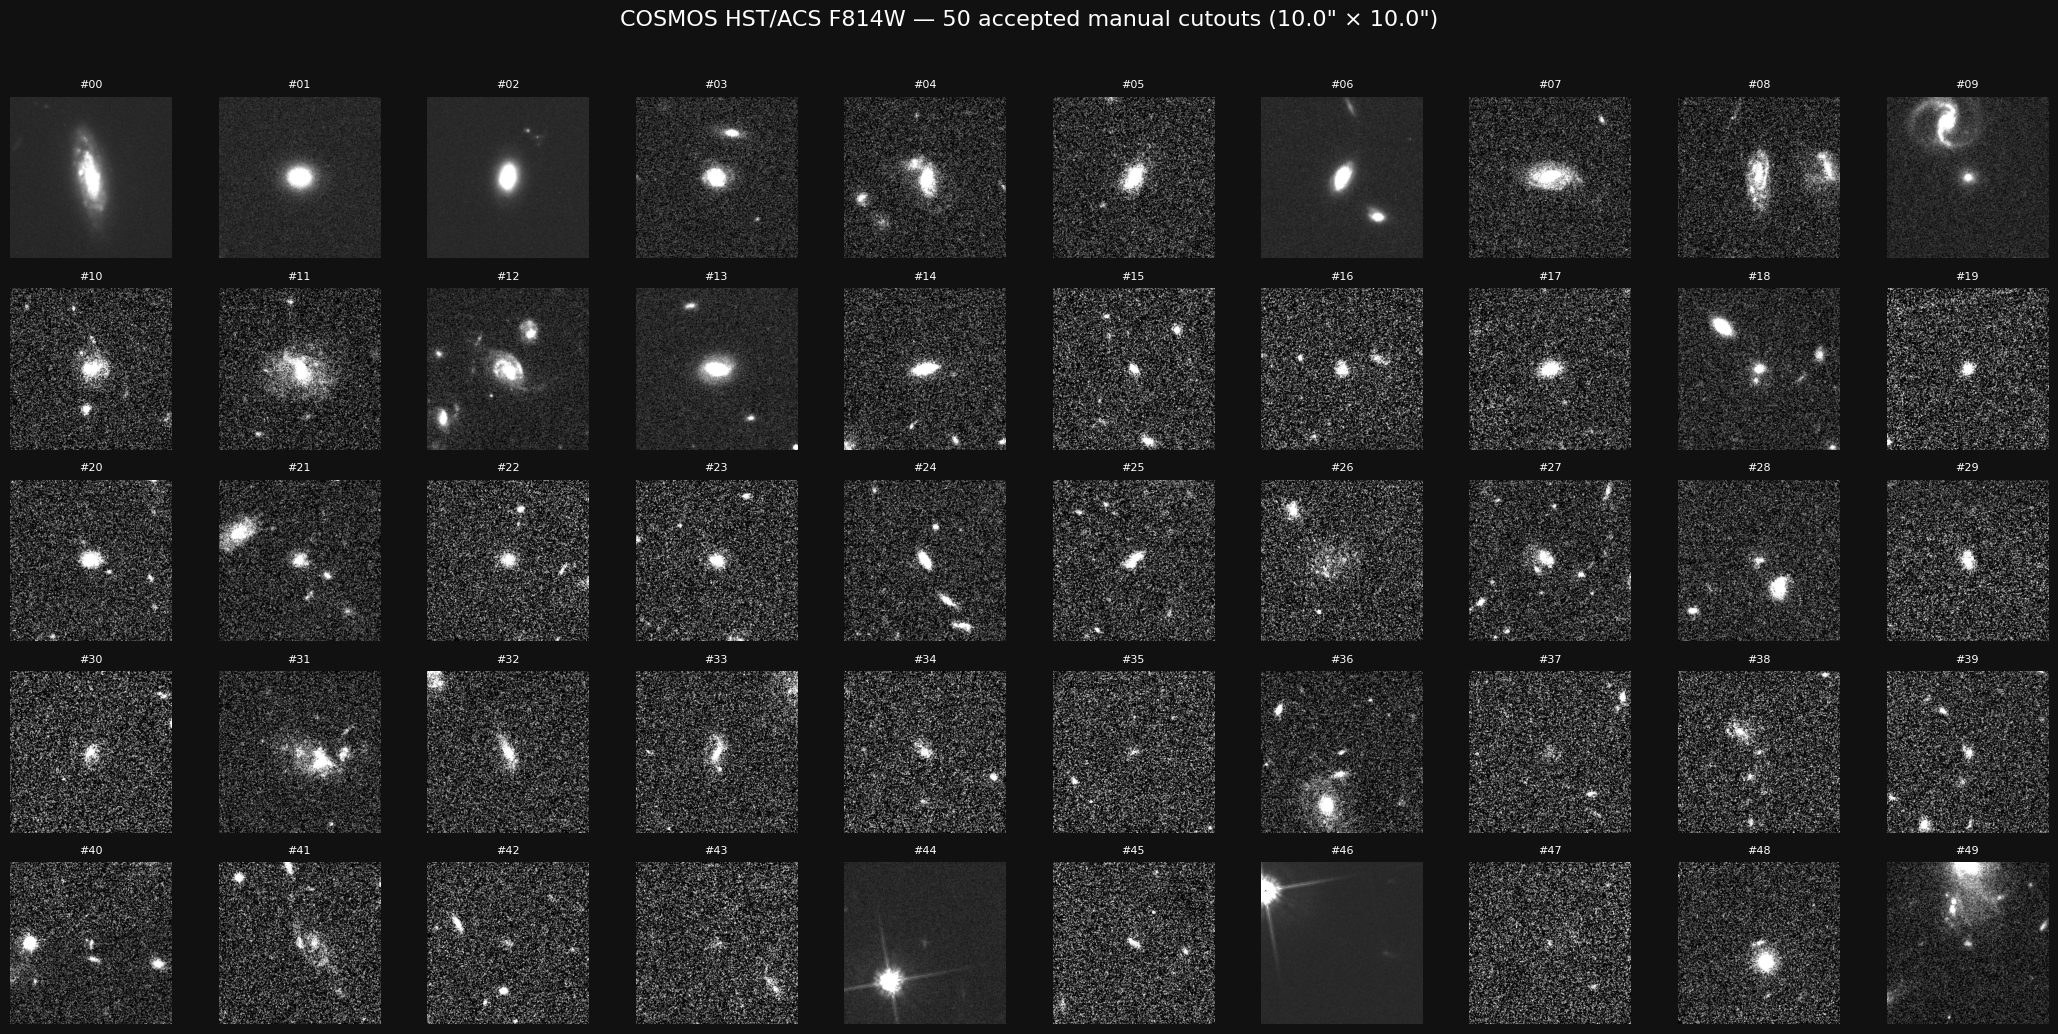

Saved grid to: C:\Users\upraj\Prajwal\GSOC\DeepLense\DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday\cosmos_cutouts\qa_plots\galaxy_grid.jpg


In [9]:
accepted_names = accepted_df['filename'].tolist()
num_accept = len(accepted_names)

if num_accept == 0:
    print('No accepted cutouts available for plotting.')
else:
    ncols = 10
    nrows = math.ceil(num_accept / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.1 * ncols, 2.1 * nrows), facecolor='#111111')

    axes = np.array(axes).reshape(nrows, ncols)
    for ax in axes.ravel():
        ax.set_facecolor('#111111')
        ax.axis('off')

    for i, name in enumerate(accepted_names):
        ax = axes.ravel()[i]
        ax.imshow(image_store[name], cmap='gray', origin='lower', vmin=-0.2, vmax=1.0)
        ax.set_title(f'#{i:02d}', color='white', fontsize=8)
        ax.axis('off')

    fig.suptitle(
        f'COSMOS HST/ACS F814W — {num_accept} accepted manual cutouts ({CUTOUT_SIZE_ARCSEC:.1f}" × {CUTOUT_SIZE_ARCSEC:.1f}")',
        color='white', fontsize=16
    )
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    grid_path = PLOT_DIR / 'galaxy_grid.jpg'
    fig.savefig(grid_path, dpi=180, facecolor=fig.get_facecolor(), bbox_inches='tight')
    plt.show()
    print('Saved grid to:', grid_path.resolve())

## Cell 11 — Quick scientific sanity checks

These checks help confirm that the exported library is internally consistent.

In [10]:
if len(accepted_df) == 0:
    print('No accepted cutouts to summarise.')
else:
    summary = accepted_df[[
        'shape_y', 'shape_x', 'pixel_scale_arcsec',
        'cutout_size_arcsec_y', 'cutout_size_arcsec_x',
        'sky_level', 'p99_flux', 'std_norm', 'peak_norm'
    ]].describe().round(4)
    display(summary)

    print('Unique shapes among accepted cutouts:')
    print(accepted_df[['shape_y', 'shape_x']].drop_duplicates().sort_values(['shape_y', 'shape_x']).to_string(index=False))

,shape_y,shape_x,pixel_scale_arcsec,cutout_size_arcsec_y,cutout_size_arcsec_x,sky_level,p99_flux,std_norm,peak_norm
count,50.0,50.0,50.00,50.00,50.00,50.0000,50.0000,50.0000,50.0000
mean,335.0,335.0,0.03,10.05,10.05,0.0002,0.0276,0.3510,4.7025
std,0.0,0.0,0.00,0.00,0.00,0.0004,0.0494,0.0613,0.6210
min,335.0,335.0,0.03,10.05,10.05,-0.0002,0.0054,0.1990,2.0438
25%,335.0,335.0,0.03,10.05,10.05,-0.0000,0.0074,0.3115,4.8254
50%,335.0,335.0,0.03,10.05,10.05,0.0001,0.0100,0.3784,5.0000
75%,335.0,335.0,0.03,10.05,10.05,0.0002,0.0155,0.3999,5.0000
max,335.0,335.0,0.03,10.05,10.05,0.0022,0.2243,0.4191,5.0000


Unique shapes among accepted cutouts:
 shape_y  shape_x
     335      335


## Cell 12 — Notes for your GSoC Stage 0 workflow

This manual-only notebook is deliberately limited to **source-library preparation**.

### What it does well
- keeps the workflow clean and reproducible,
- prevents the metadata RA/Dec bug by storing true coordinates,
- guarantees `.npy` export verification,
- adds simple image-level QA and manual rejection support.

### What it does **not** do
- no automatic IRSA querying,
- no catalog-based star rejection,
- no morphology-based catalog cuts,
- no lenstronomy injection yet.

### Recommended workflow
1. Build your target list elsewhere.
2. Download only the cutouts you actually want.
3. Put them in `RAW_DIR`.
4. Run this notebook.
5. Review `qa_plots/galaxy_grid.jpg` and `rejected_cutouts.csv`.
6. Add bad files to `REJECT_BY_FILENAME` if needed and rerun Cells 5 onward.
7. Use the resulting `.npy` files as source inputs for your next lenstronomy notebook.